In [1]:
# Modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots

plt.style.use('science')
cmap = mcolors.LinearSegmentedColormap.from_list("", ["blue","blueviolet", "mediumorchid","deeppink","red"])
norm = mcolors.Normalize(vmin=4, vmax=8)
eq_temp = 1/(1+(100/np.pi-1)*4172.4/1836.0)

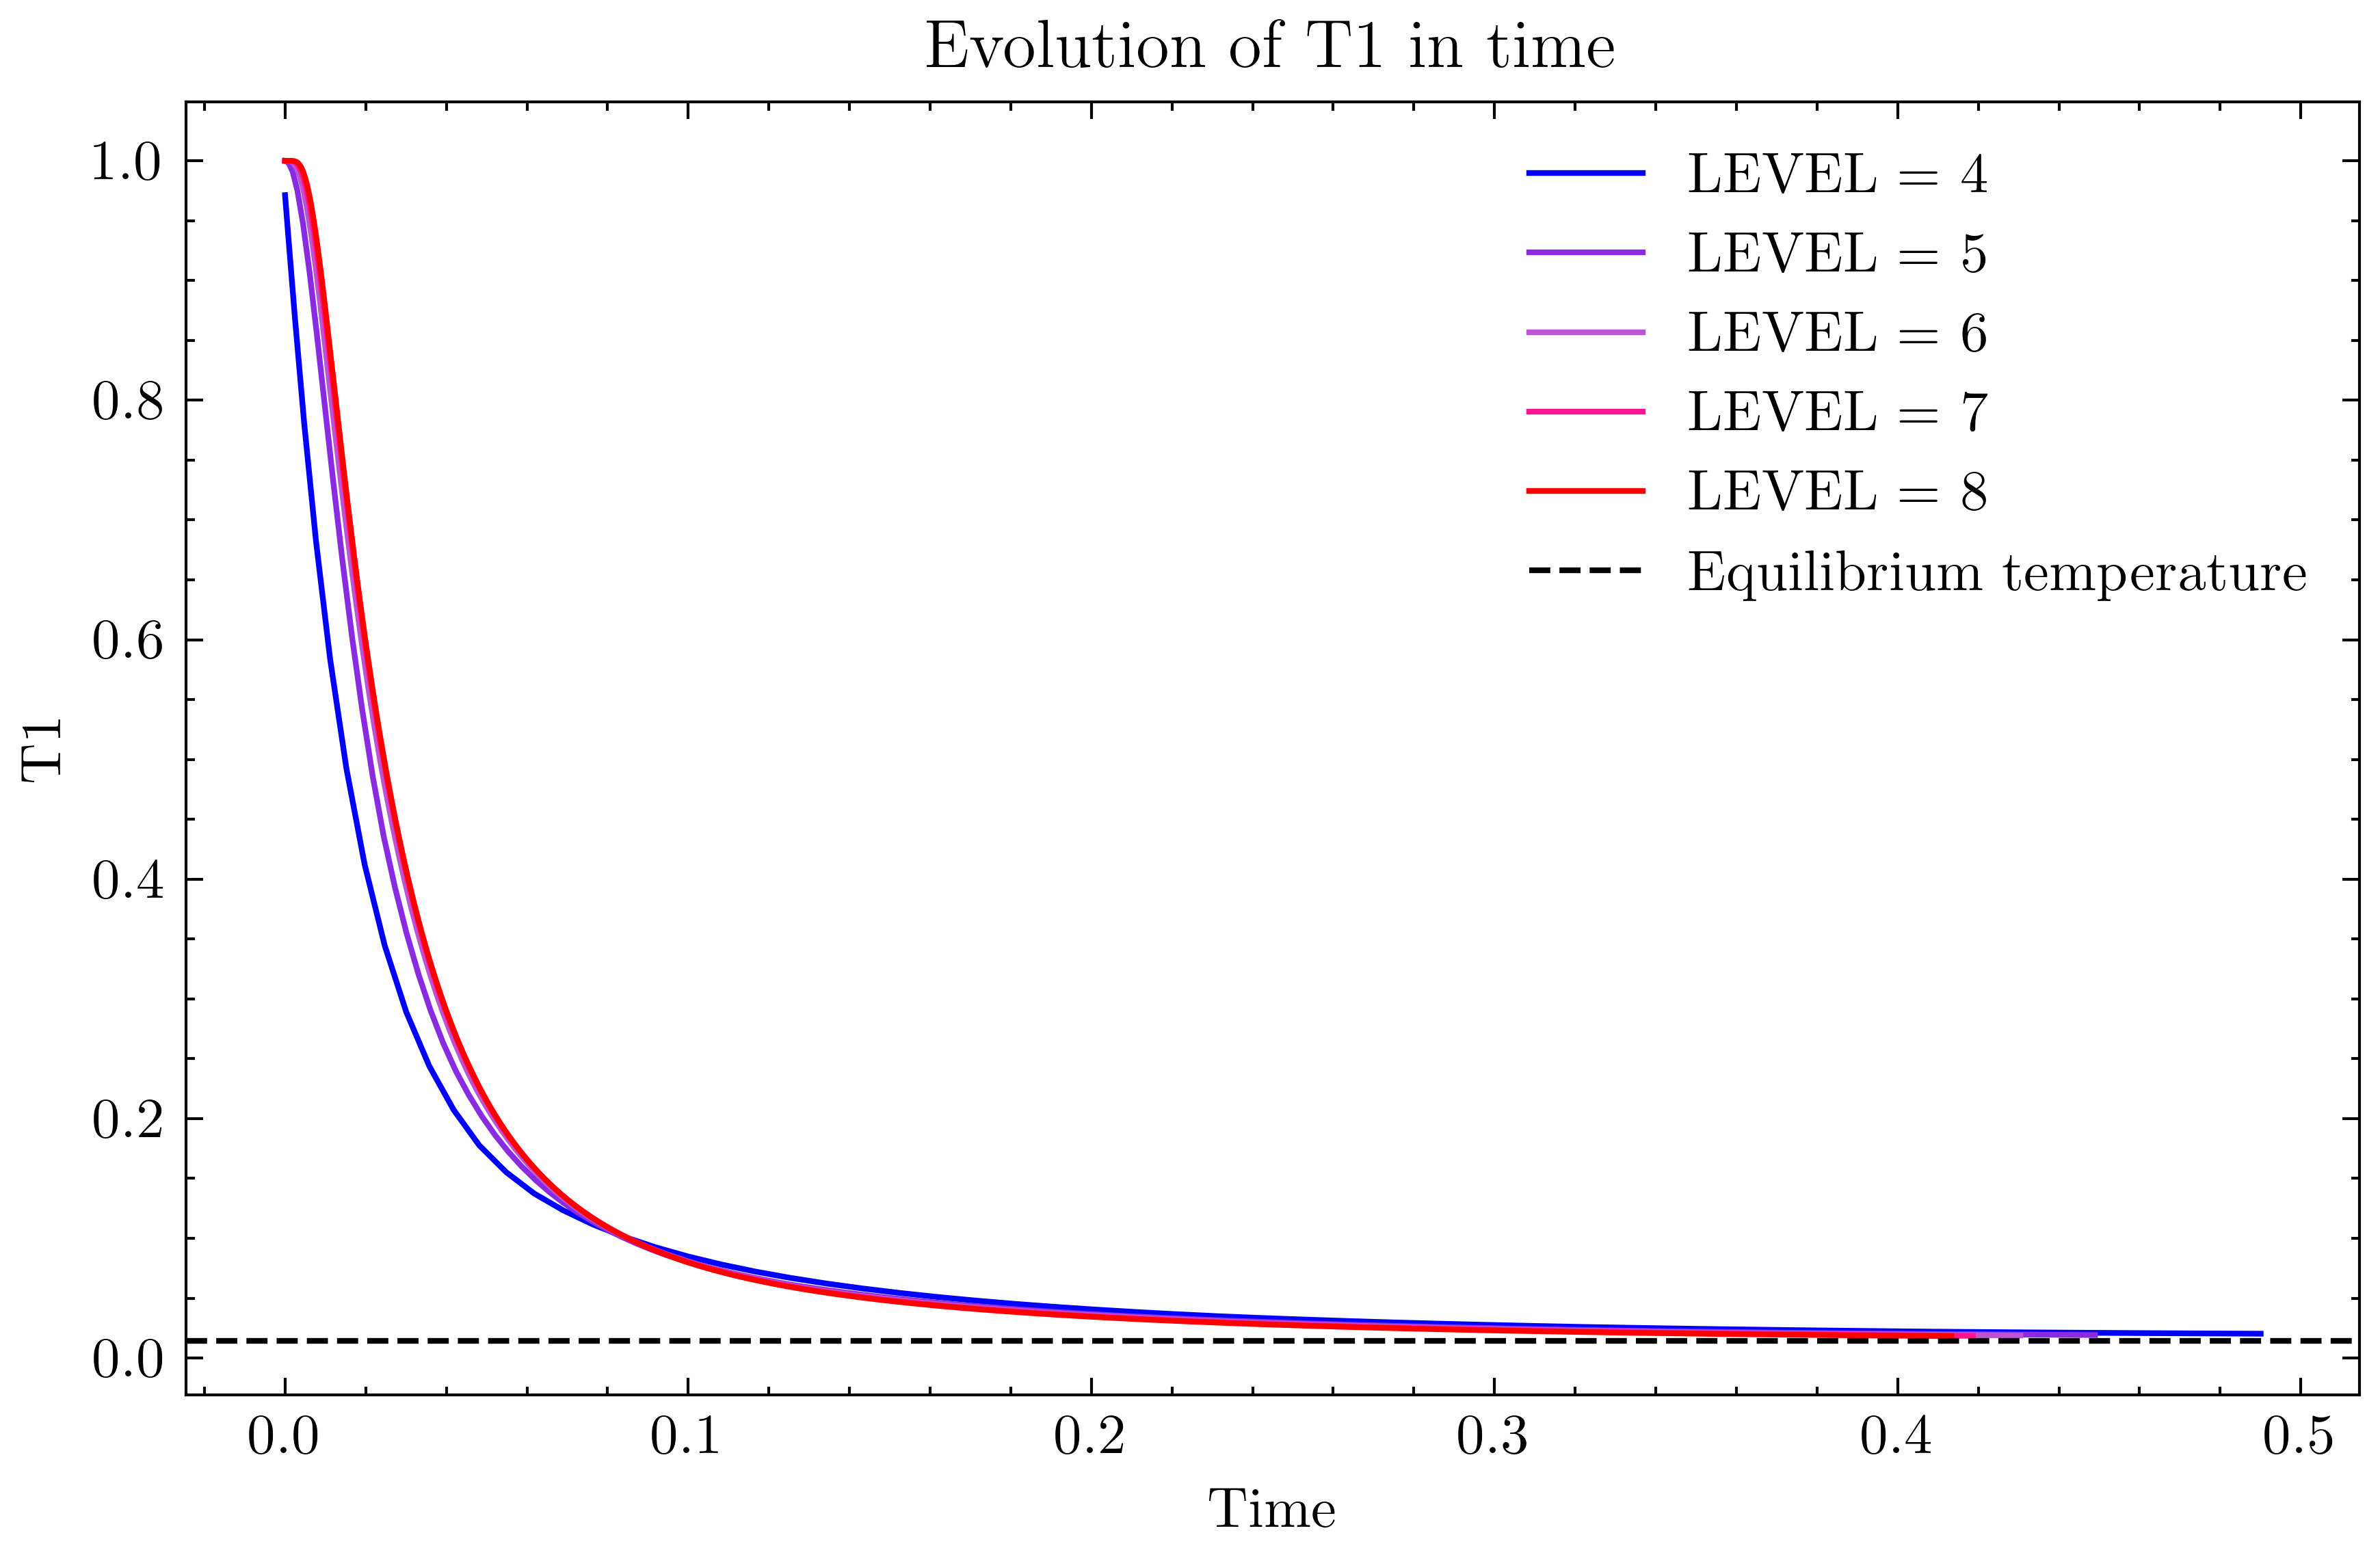

In [2]:
# We plot the graph of  evolution of enthalpy in time
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_ylabel("T1")
ax.set_title("Evolution of T1 in time")

for i in range(4,9):
    data = np.loadtxt(f"LEVEL_{i}/data.vof")
    time = data[:,0]
    T1 = data[:,1]
    graph_color = cmap(norm(i))
    ax.plot(time, T1, color = graph_color, label = f"LEVEL = {i}")

plt.axhline(y=eq_temp, color='k', linestyle='--', label = "Equilibrium temperature")
ax.legend()
plt.tight_layout()
plt.savefig("Figures/Error of T1 in time.png",dpi=600)
plt.show()

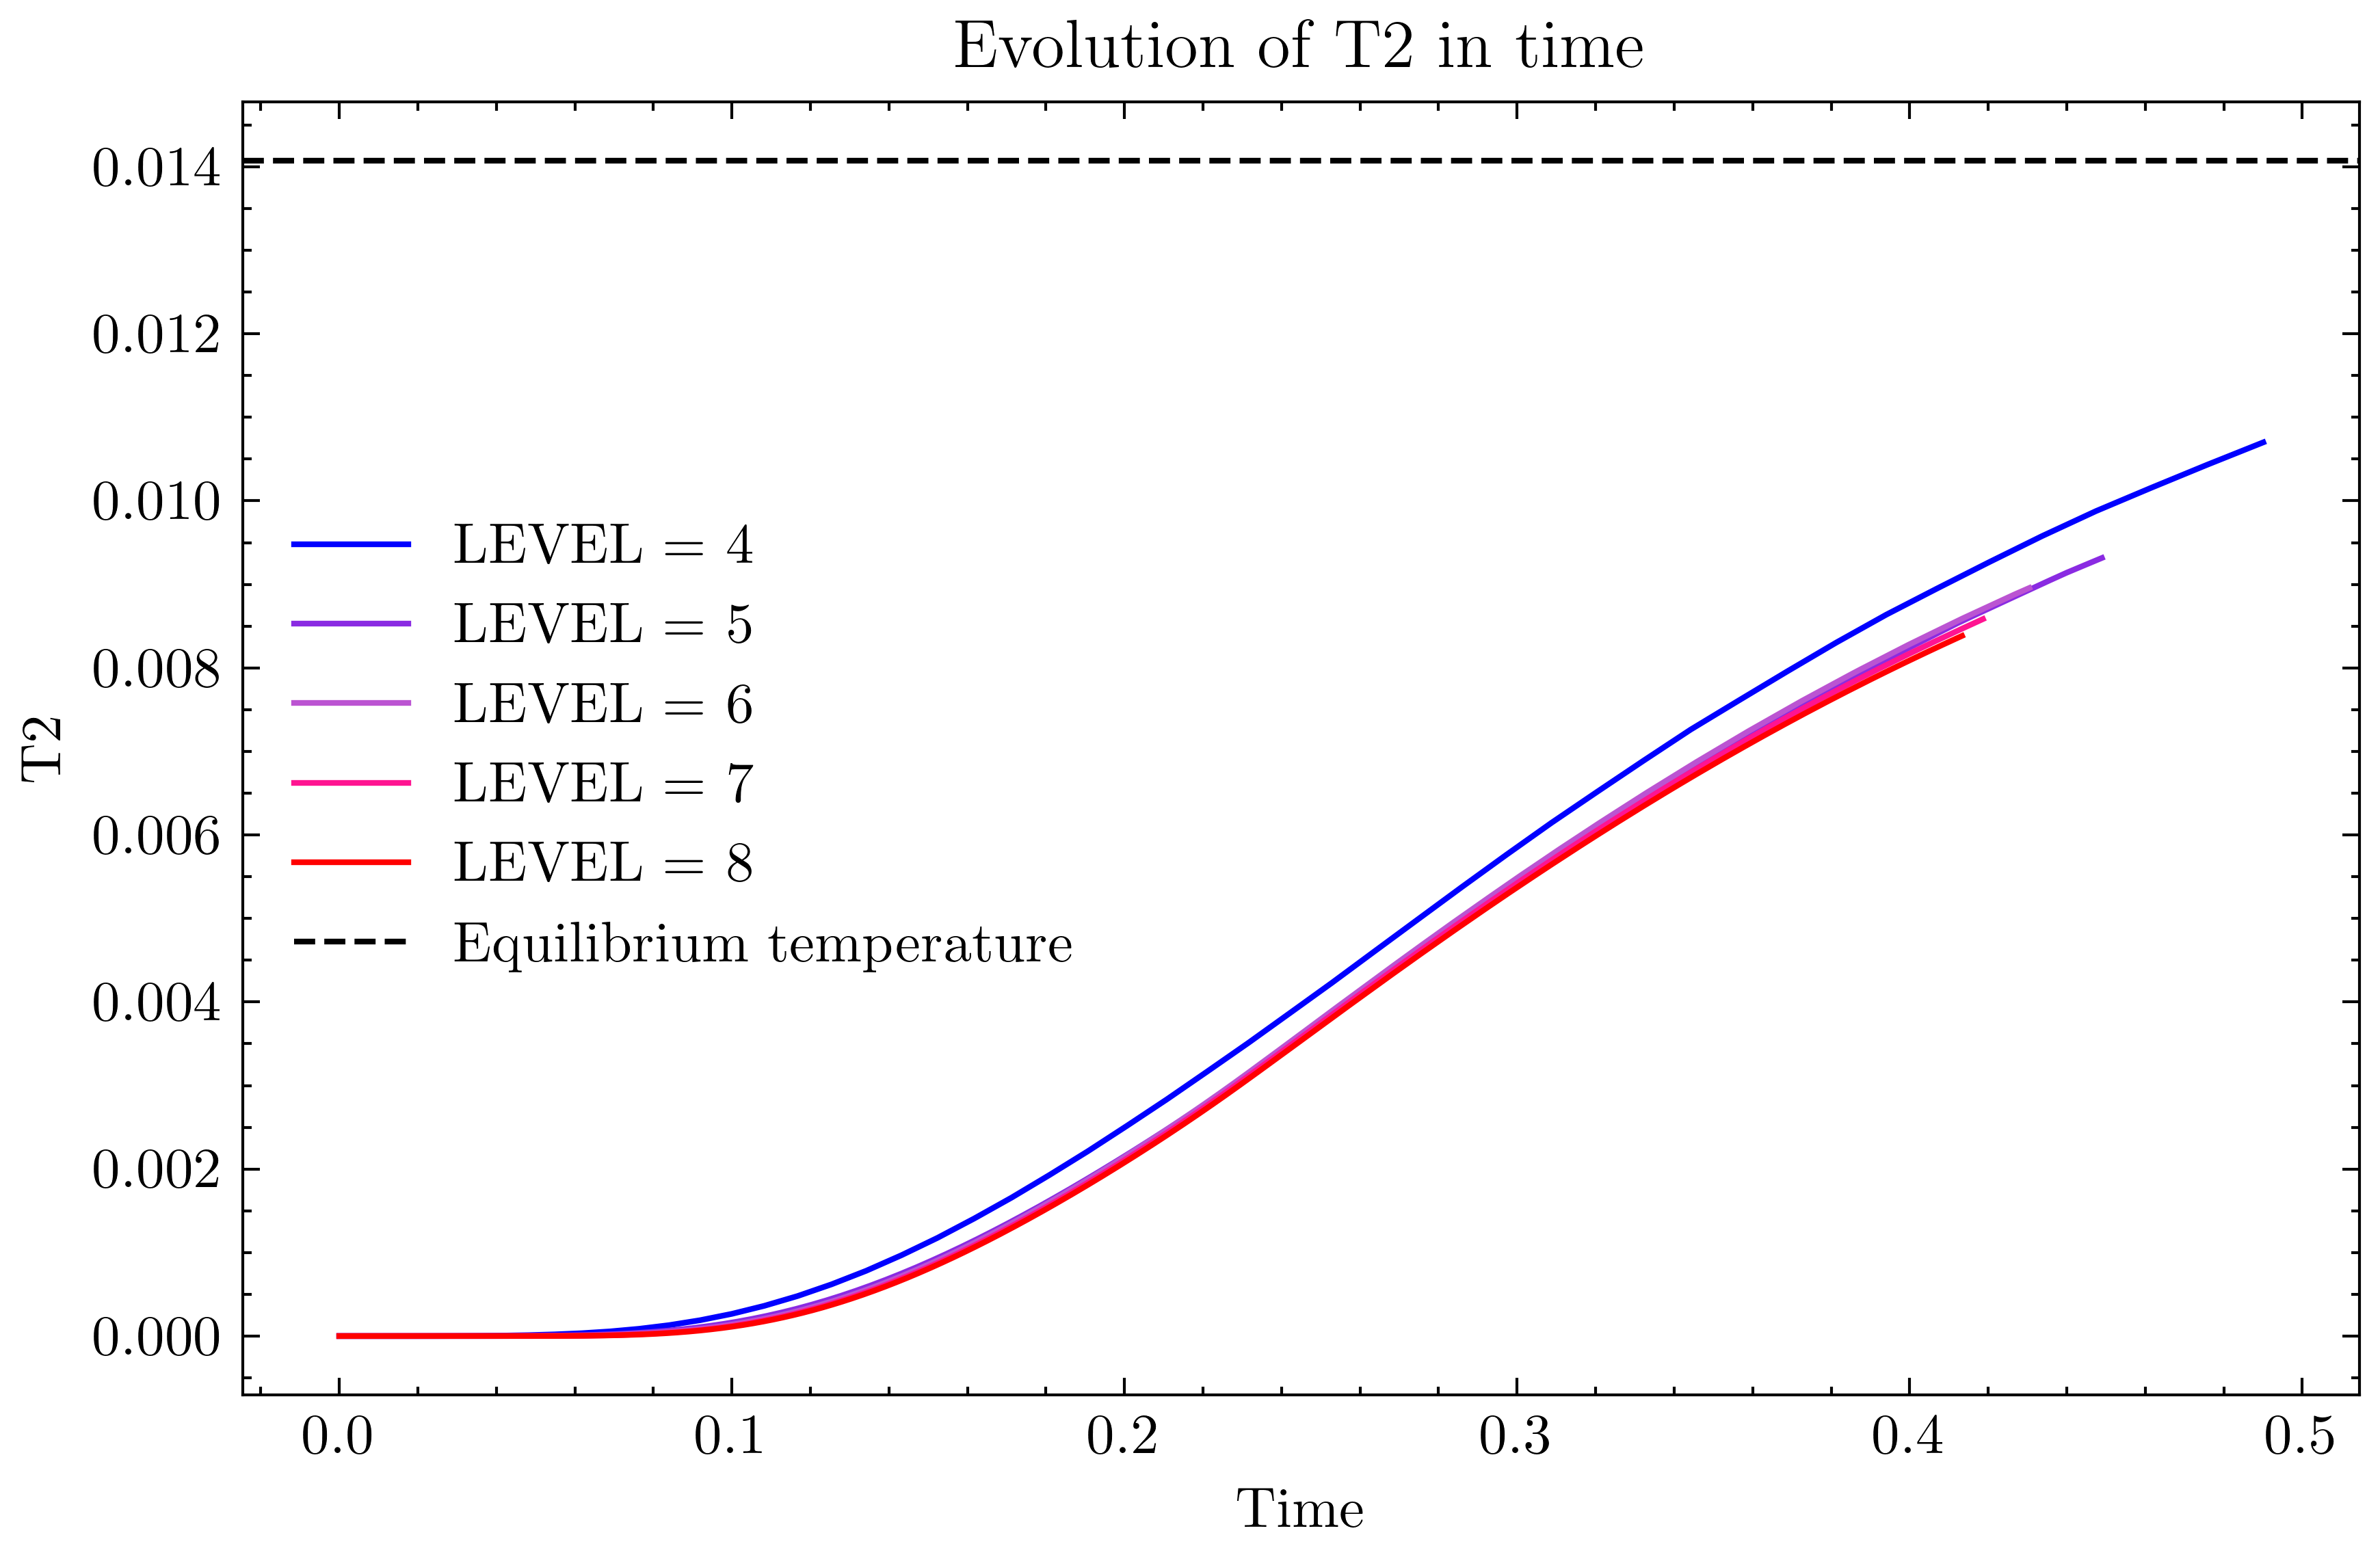

In [3]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_ylabel("T2")
ax.set_title("Evolution of T2 in time")

for i in range(4,9):
    data = np.loadtxt(f"LEVEL_{i}/data.vof")
    time = data[:,0]
    T2 = data[:,2]
    graph_color = cmap(norm(i))
    ax.plot(time, T2, color = graph_color, label = f"LEVEL = {i}")

plt.axhline(y=eq_temp, color='k', linestyle='--', label = "Equilibrium temperature")
ax.legend()
plt.tight_layout()
plt.savefig("Figures/Error of T2 in time.png",dpi=600)
plt.show()

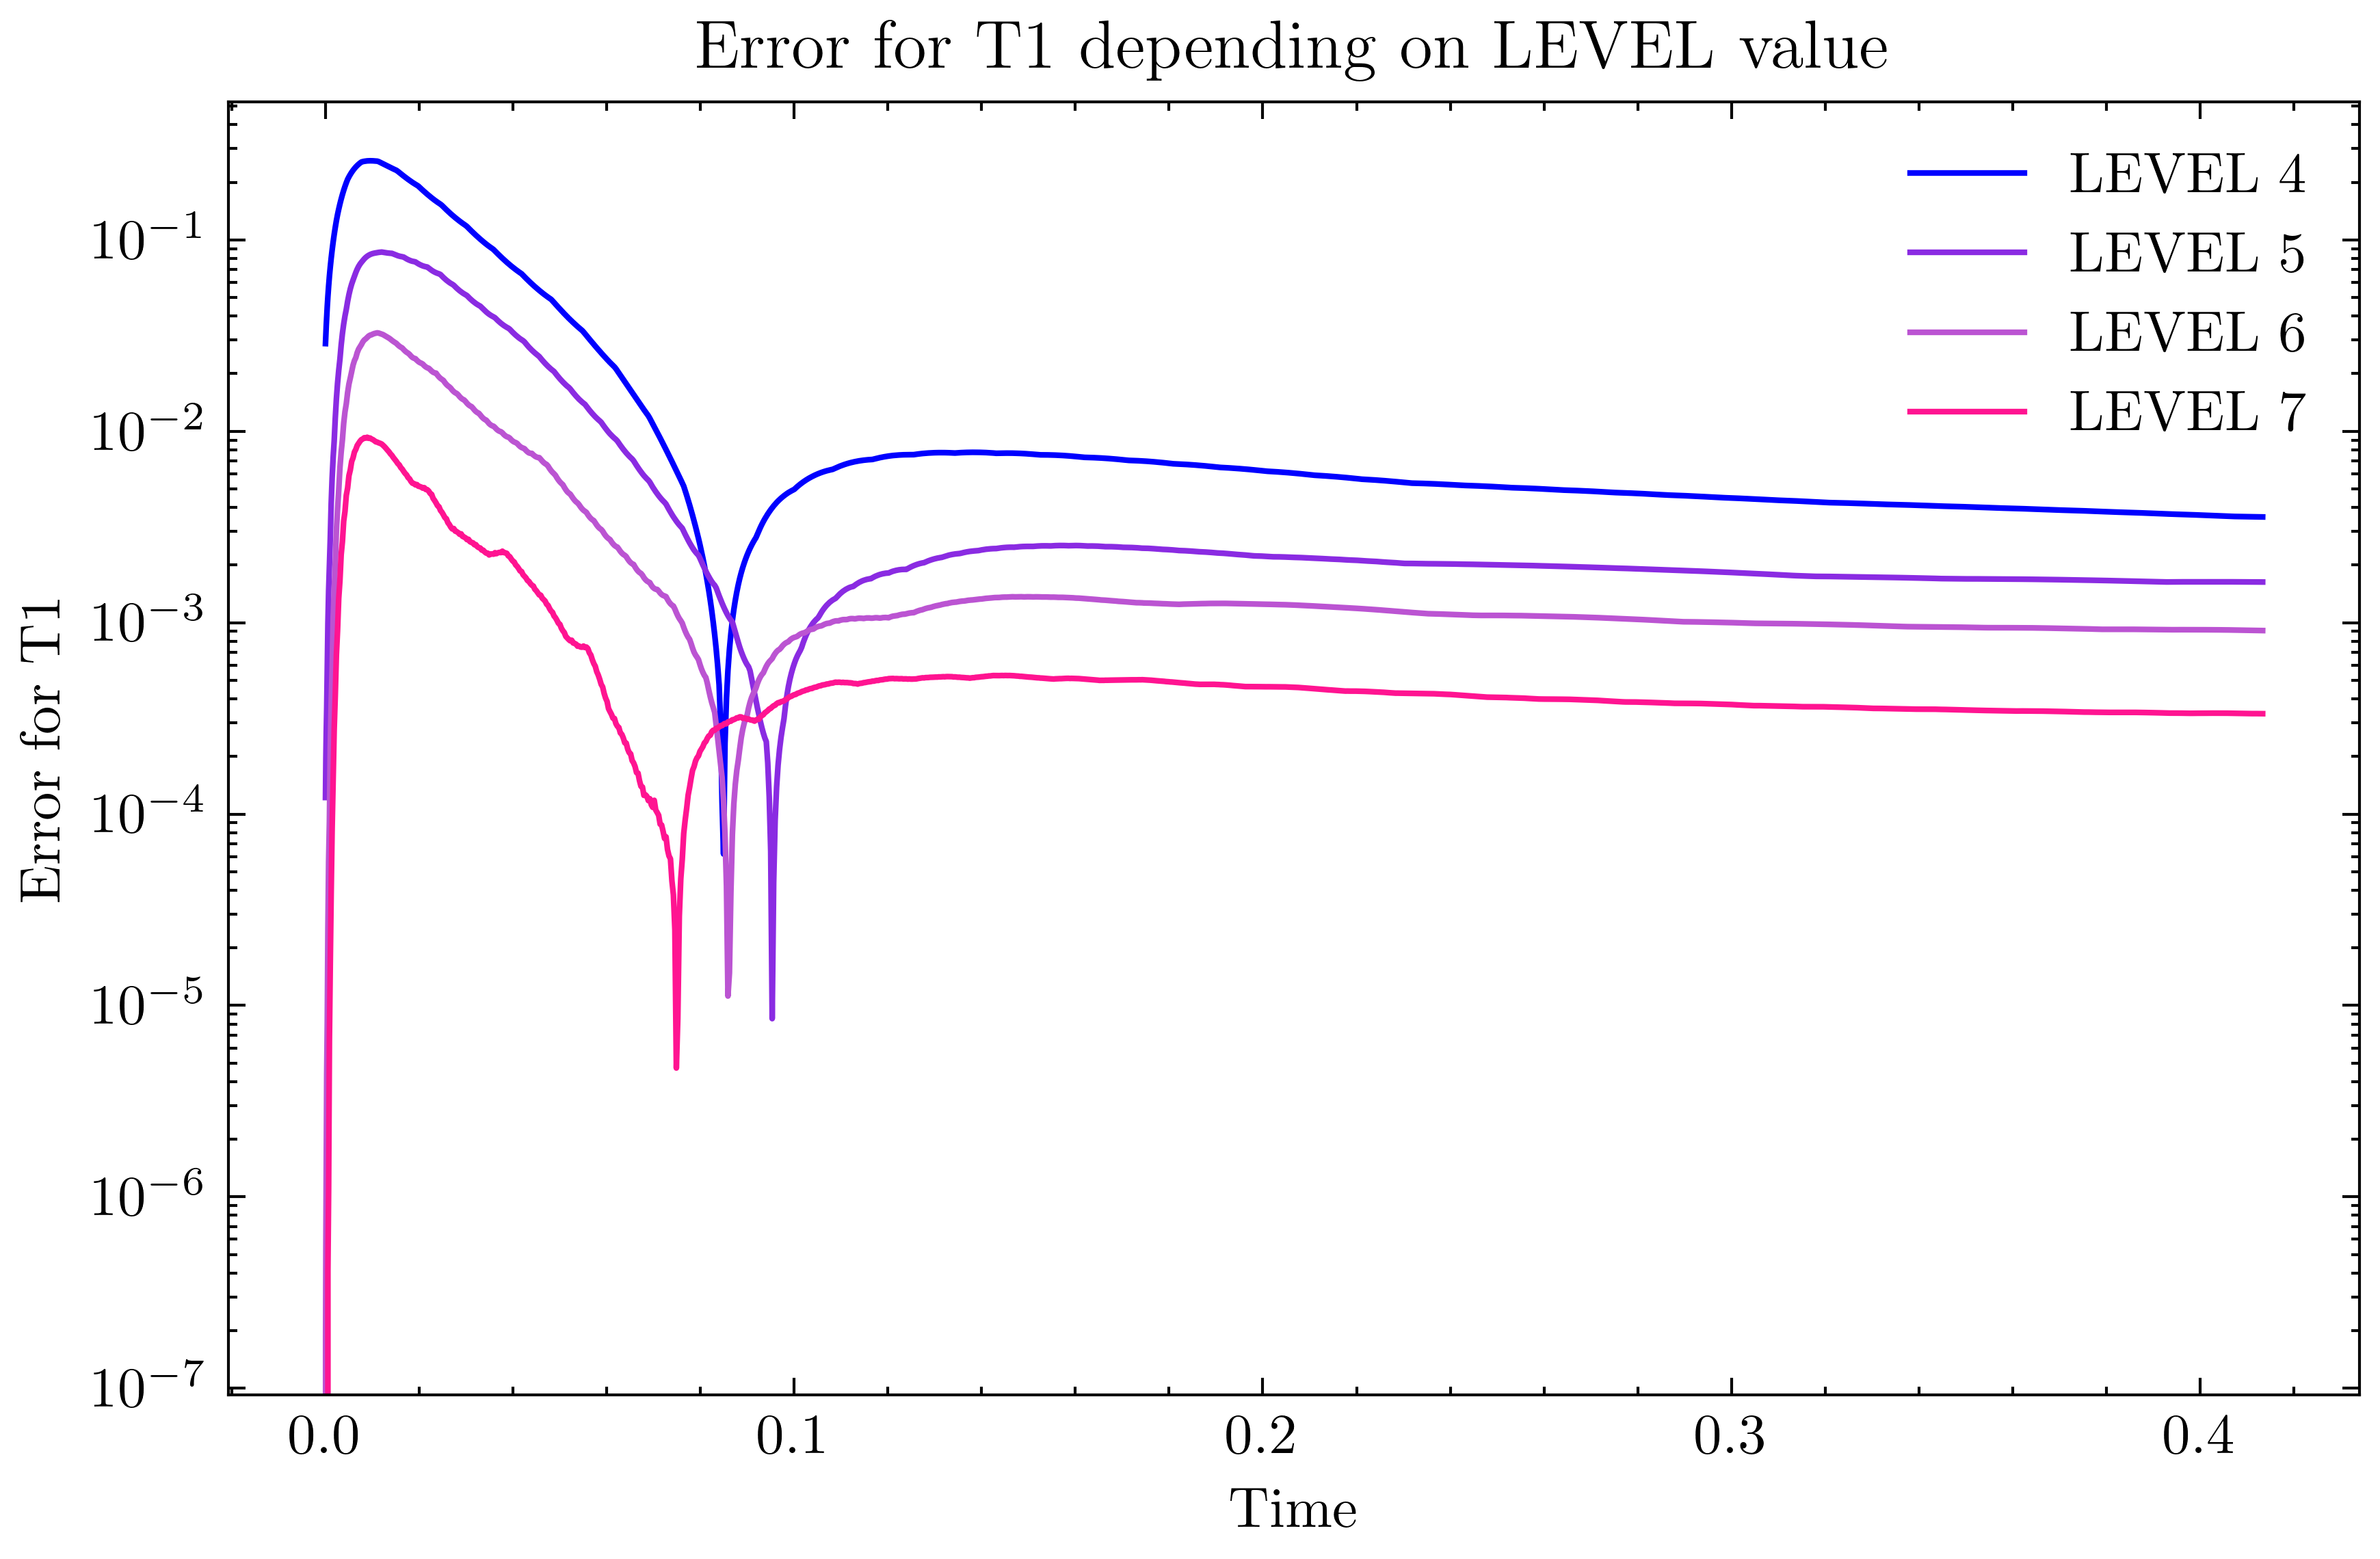

In [4]:
erreur_T1_moy = []

data_ref = np.loadtxt("LEVEL_8/data.vof")
t_ref = data_ref[:, 0]
T1_ref = data_ref[:, 1]

fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_ylabel("Error for T1")
ax.set_yscale("log")
ax.set_title("Error for T1 depending on LEVEL value")

for i in range(4,8):
    data_i = np.loadtxt(f"LEVEL_{i}/data.vof")
    t_i = data_i[:, 0]
    T1_i = data_i[:, 1]
    T1_i_interp = np.interp(t_ref, t_i, T1_i)
    erreur_T1 = np.abs(T1_i_interp - T1_ref)
    erreur_T1_moy.append(np.mean(np.abs(erreur_T1)))
    graph_color = cmap(norm(i))
    ax.plot(t_ref, erreur_T1, color = graph_color, label=f"LEVEL {i}",)

ax.legend()
plt.tight_layout()
plt.savefig("Figures/Error for T1 depending on LEVEL value.png",dpi=600)
plt.show()

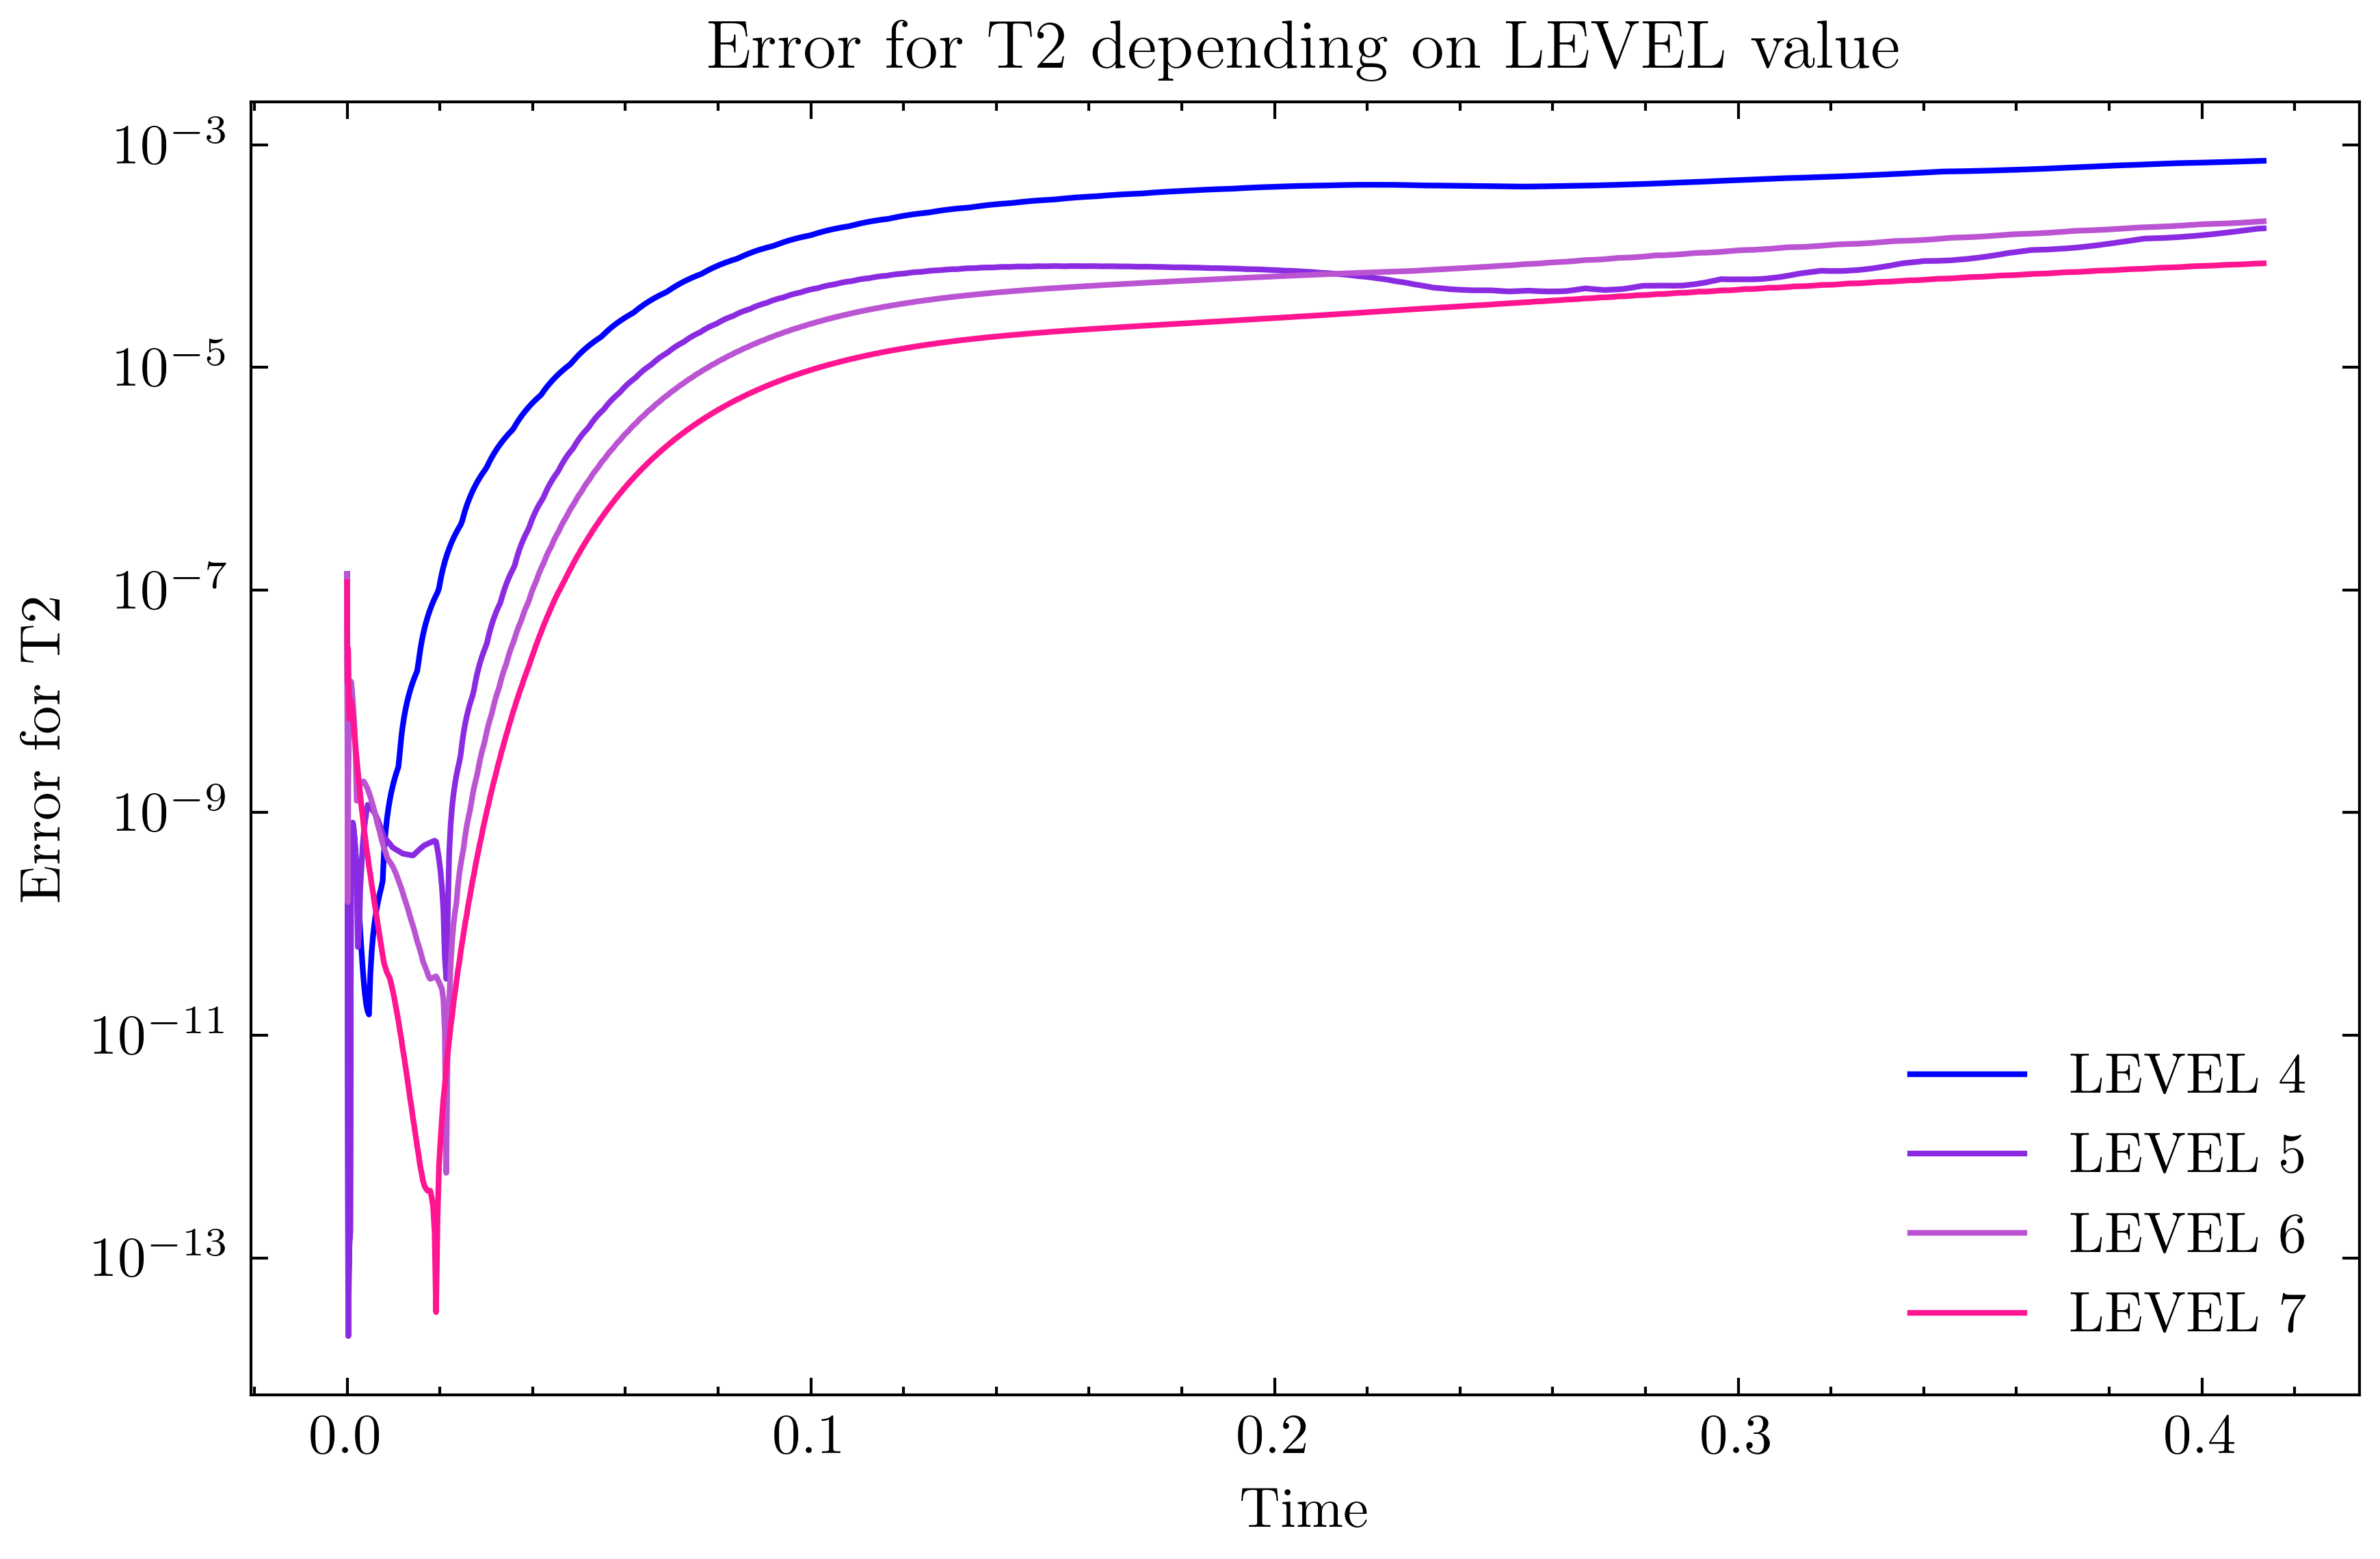

In [5]:
erreur_T2_moy = []

data_ref = np.loadtxt("LEVEL_8/data.vof")
t_ref = data_ref[:, 0]
T2_ref = data_ref[:, 2]

fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_yscale("log")
ax.set_ylabel("Error for T2")
ax.set_title("Error for T2 depending on LEVEL value")

for i in range(4,8):
    data_i = np.loadtxt(f"LEVEL_{i}/data.vof")
    t_i = data_i[:, 0]
    T2_i = data_i[:, 2]
    T2_i_interp = np.interp(t_ref, t_i, T2_i)
    erreur_T2 = np.abs(T2_i_interp - T2_ref)
    erreur_T2_moy.append(np.mean(np.abs(erreur_T2)))
    graph_color = cmap(norm(i))
    ax.plot(t_ref, erreur_T2, color = graph_color, label=f"LEVEL {i}")

ax.legend()
plt.tight_layout()
plt.savefig("Figures/Error for T2 depending on LEVEL value.png",dpi=600)
plt.show()

The error for T1 is 1.66
The error for T2 is 1.14


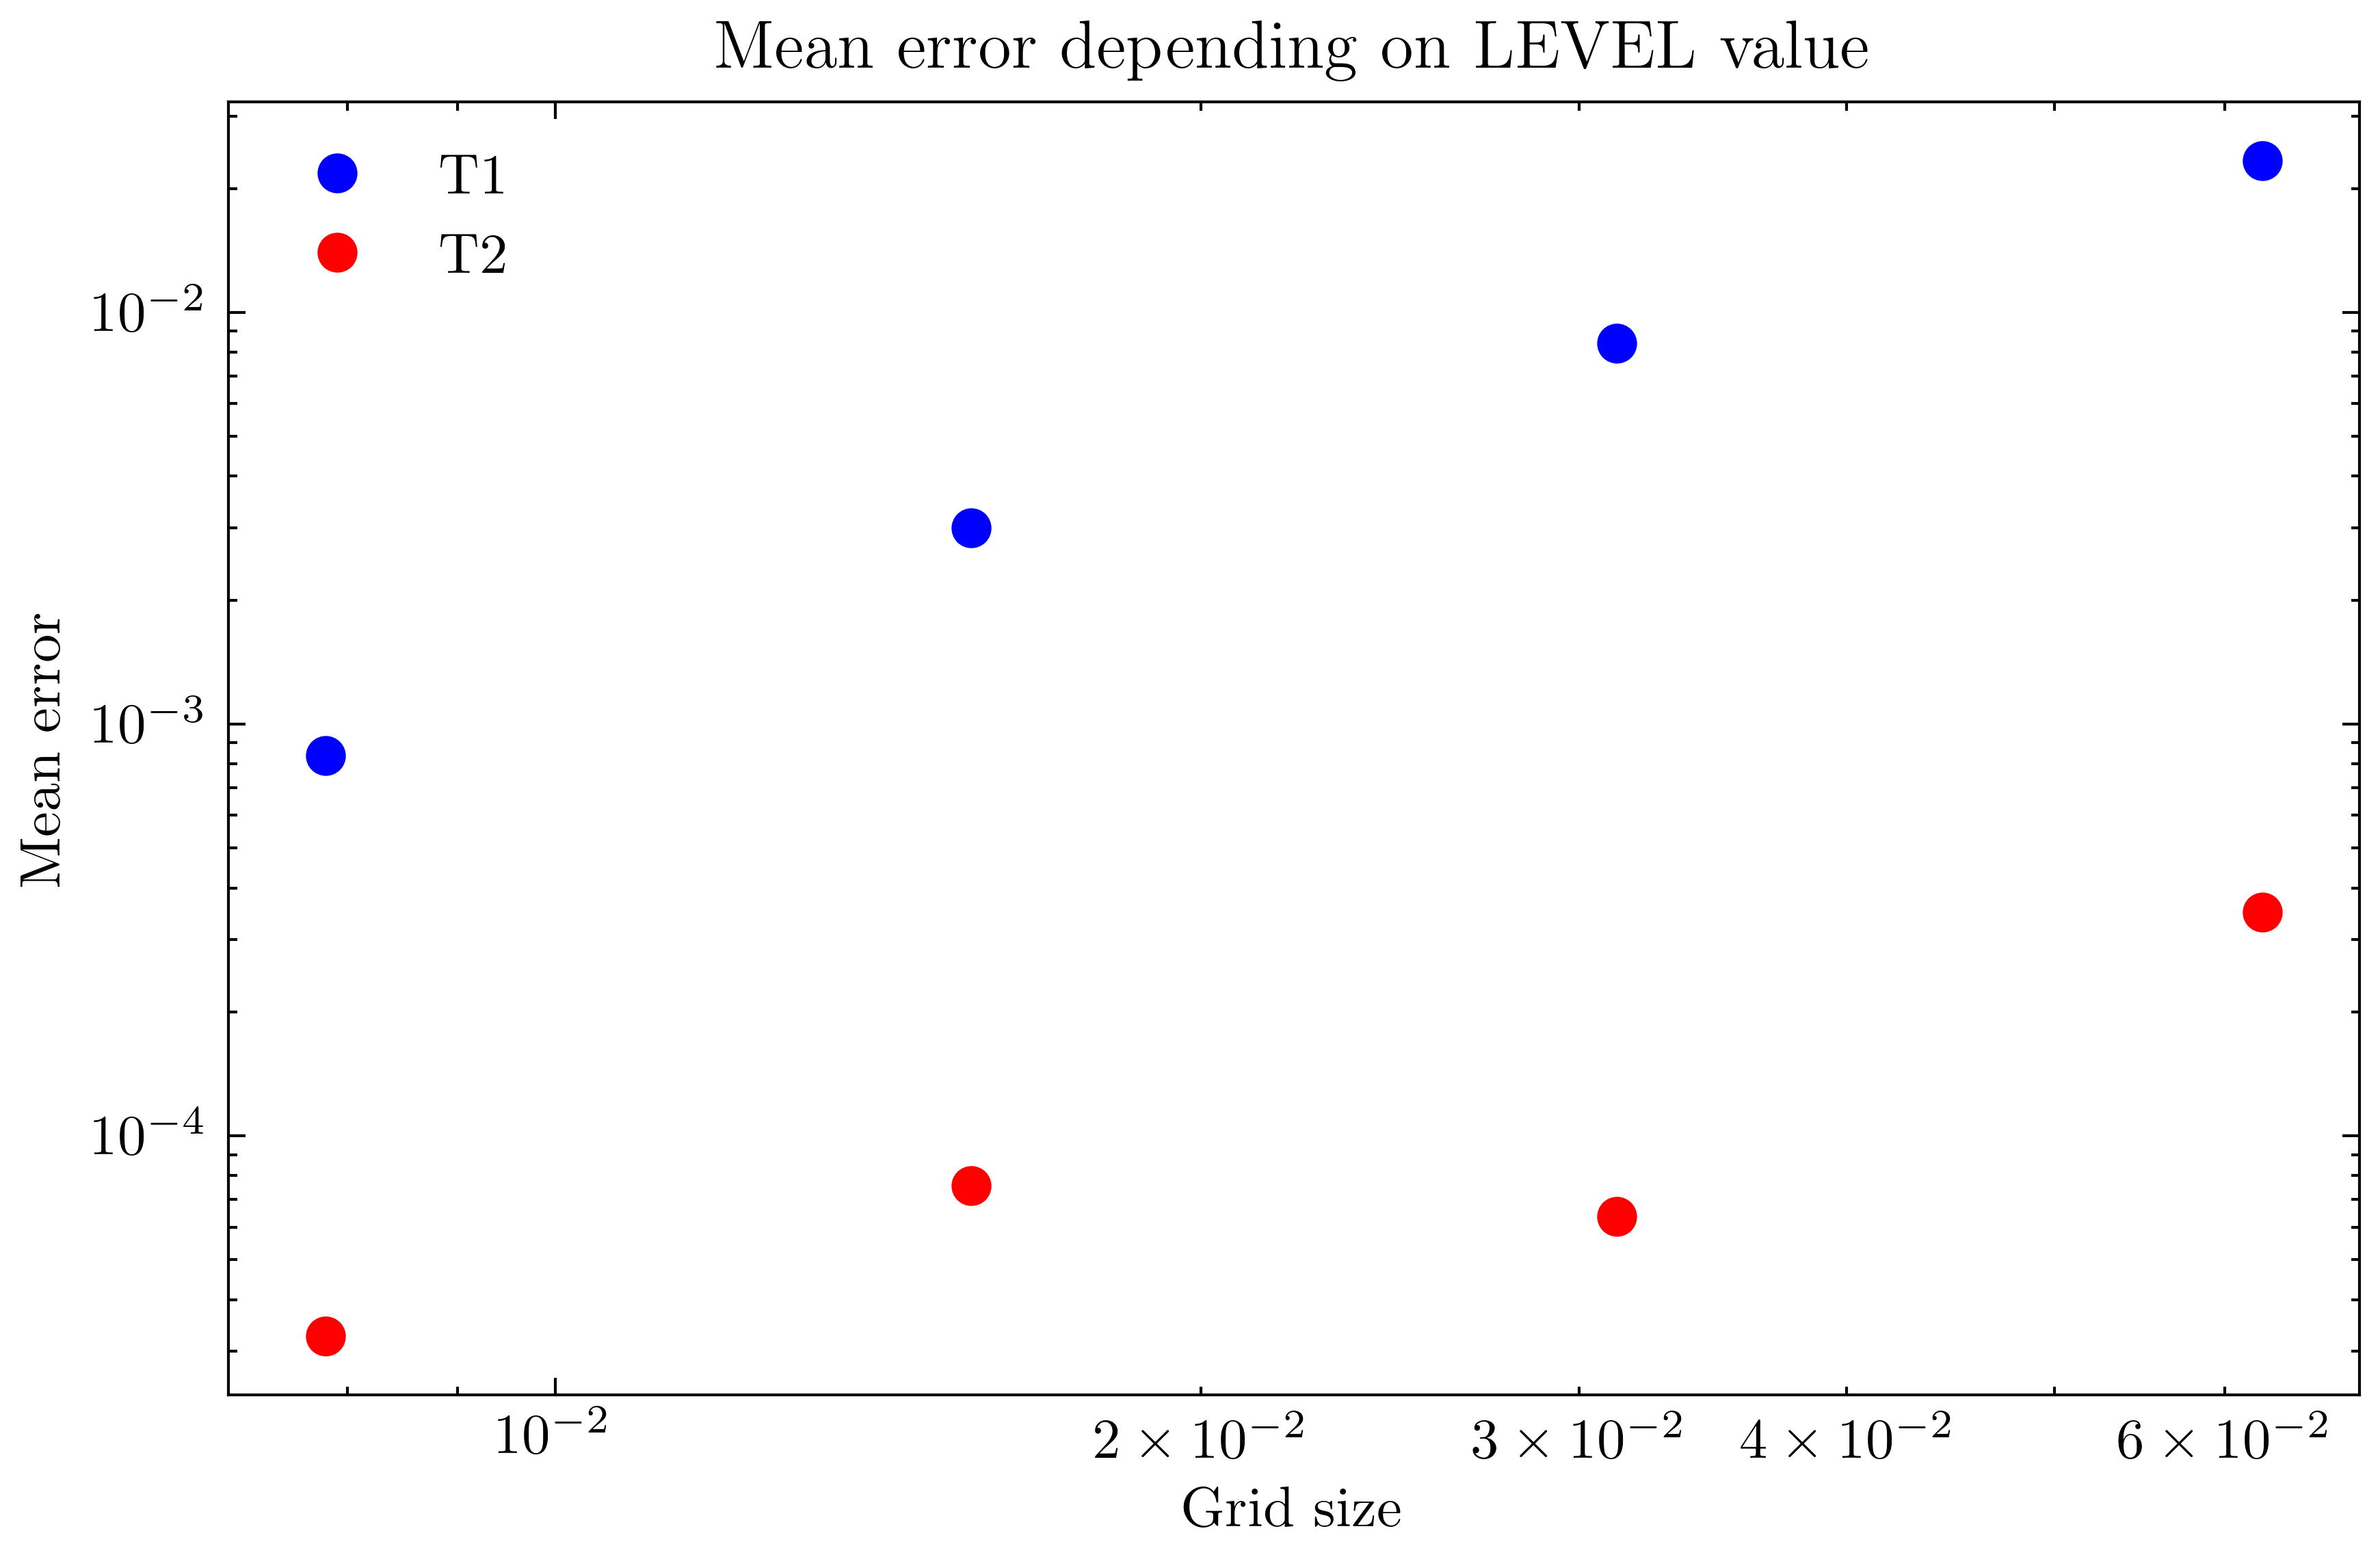

In [6]:
grid_size = np.array([2**(-4),2**(-5),2**(-6),2**(-7)])

fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Grid size")
ax.set_ylabel("Mean error")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title("Mean error depending on LEVEL value")

ax.plot(grid_size,erreur_T1_moy, 'o', color = "blue", label="T1")
ax.plot(grid_size,erreur_T2_moy, 'o', color = "red", label="T2")
power1 = np.polyfit(np.log(grid_size)[1:], np.log(erreur_T1_moy)[1:], deg = 1)[0]
power2 = np.polyfit(np.log(grid_size)[[0,2,3]], np.log(erreur_T2_moy)[[0,2,3]], deg = 1)[0]
print(f"The error for T1 is {power1:.2f}")
print(f"The error for T2 is {power2:.2f}")
ax.legend()
plt.tight_layout()
plt.savefig("Figures/Mean error depending on Grid size.png",dpi=600)
plt.show()

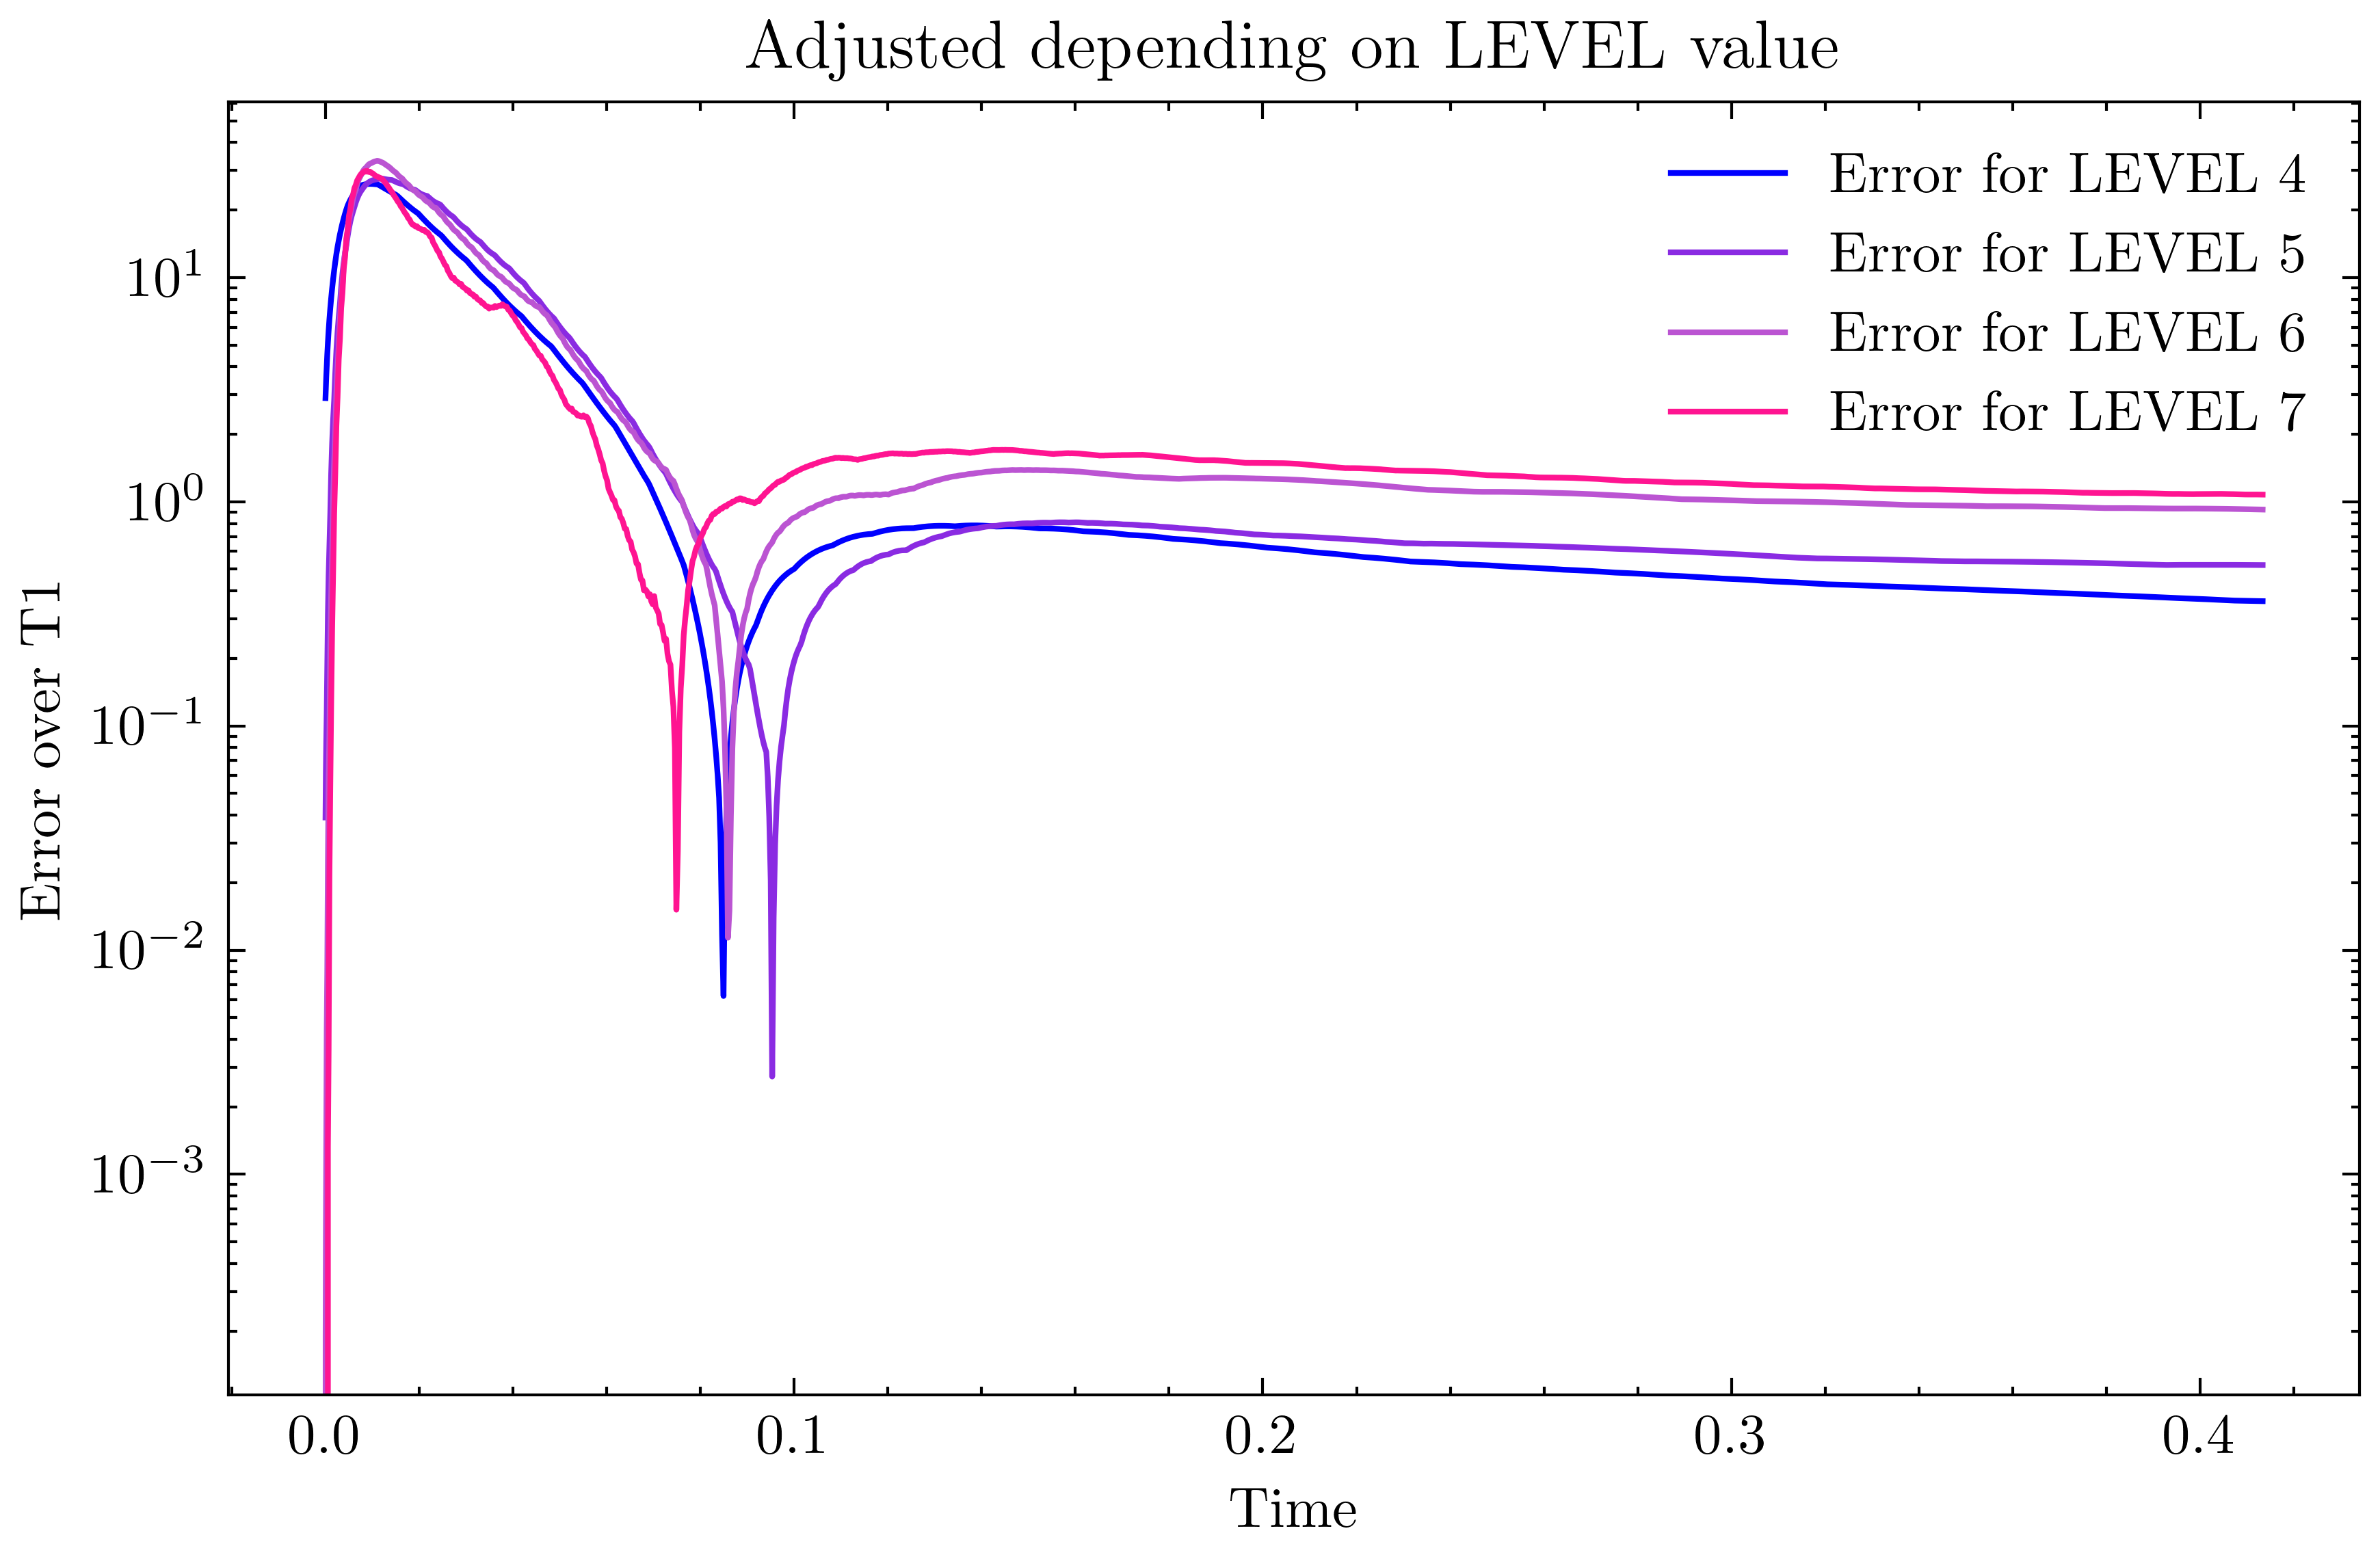

In [7]:
data_ref = np.loadtxt("LEVEL_8/data.vof")
t_ref = data_ref[:, 0]
T1_ref = data_ref[:, 1]

fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_ylabel("Error over T1")
ax.set_yscale("log")
ax.set_title("Adjusted depending on LEVEL value")

for i in range(4,8):
    data_i = np.loadtxt(f"LEVEL_{i}/data.vof")
    t_i = data_i[:, 0]
    T1_i = data_i[:, 1]
    T1_i_interp = np.interp(t_ref, t_i, T1_i)
    erreur_T1 = np.abs(T1_i_interp - T1_ref)
    graph_color = cmap(norm(i))
    ax.plot(t_ref, erreur_T1/grid_size[i-4]**power1, color = graph_color, label=f"Error for LEVEL {i}",)

ax.legend()
plt.tight_layout()
plt.savefig("Figures/Adjusted error for T1 depending on LEVEL value.png",dpi=600)
plt.show()

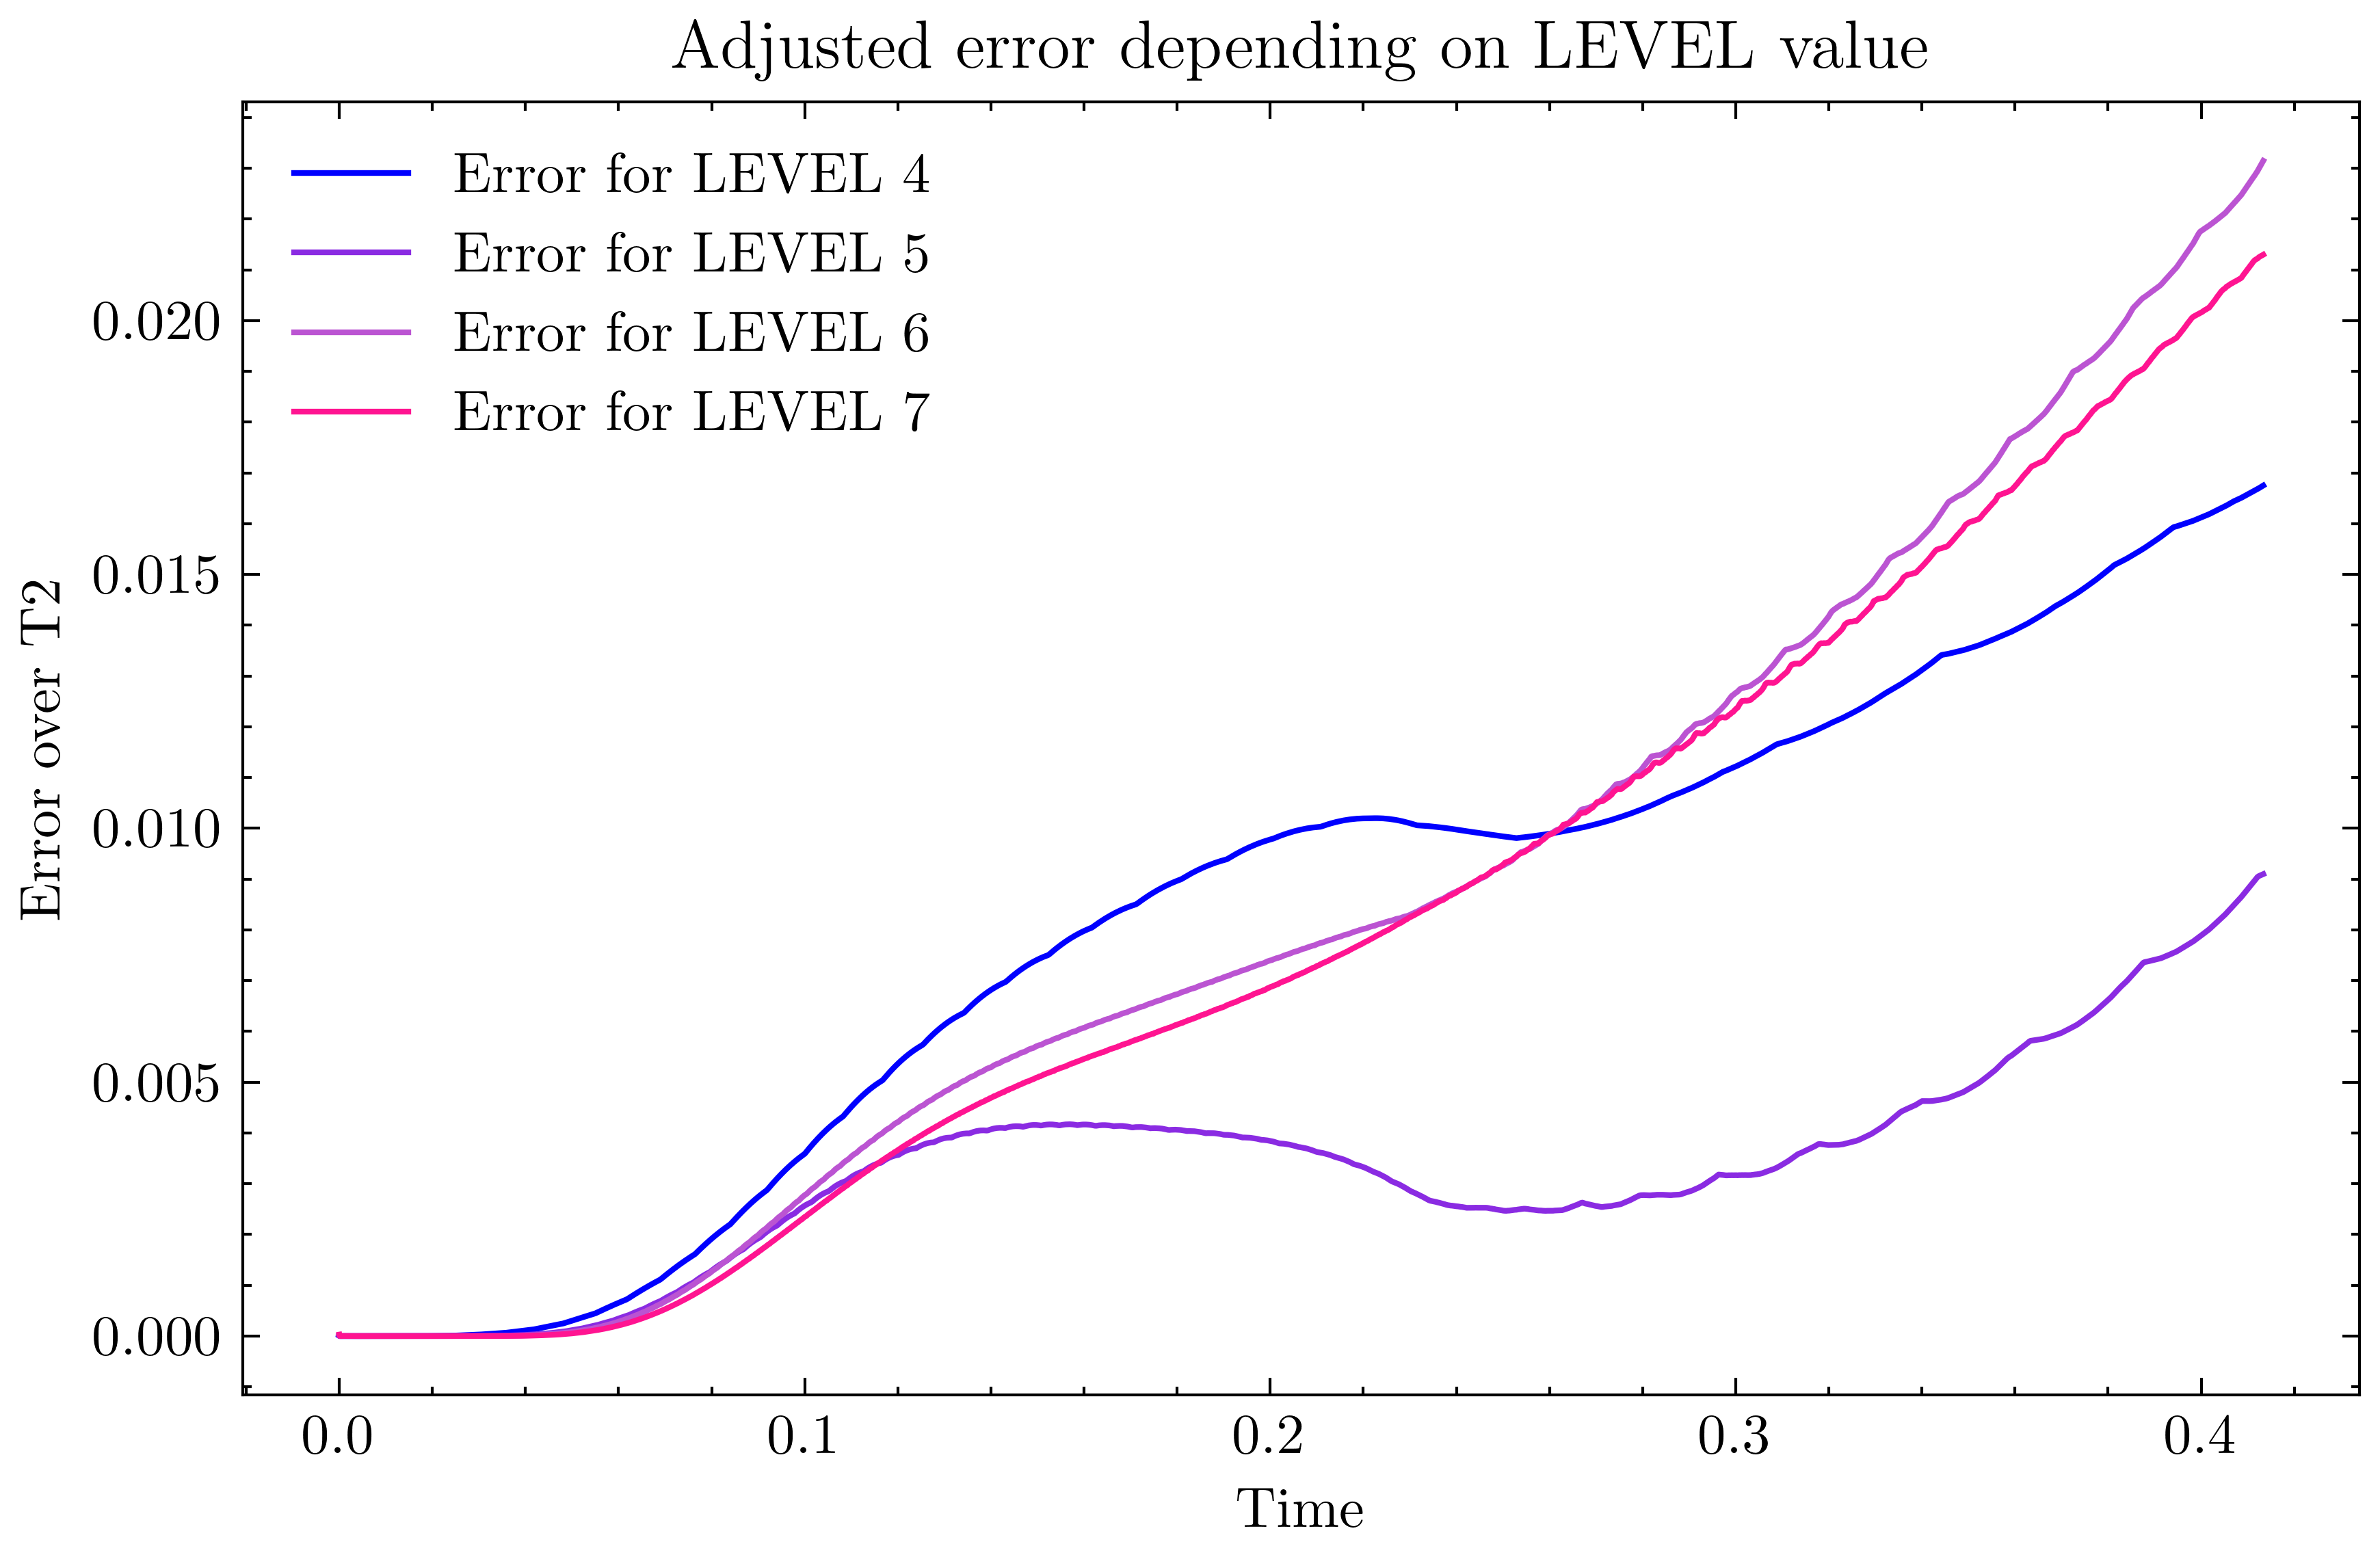

In [8]:
data_ref = np.loadtxt("LEVEL_8/data.vof")
t_ref = data_ref[:, 0]
T2_ref = data_ref[:, 2]

fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_ylabel("Error over T2")
ax.set_title("Adjusted error depending on LEVEL value")

for i in range(4,8):
    data_i = np.loadtxt(f"LEVEL_{i}/data.vof")
    t_i = data_i[:, 0]
    T2_i = data_i[:, 2]
    T2_i_interp = np.interp(t_ref, t_i, T2_i)
    erreur_T2 = np.abs(T2_i_interp - T2_ref)
    graph_color = cmap(norm(i))
    ax.plot(t_ref, erreur_T2/grid_size[i-4]**power2, color = graph_color, label=f"Error for LEVEL {i}",)

ax.legend()
plt.tight_layout()
plt.savefig("Figures/Adjusted error for T2 depending on LEVEL value.png",dpi=600)
plt.show()